In [ ]:
%%bash
# download induced phage assemblies
mkdir -p induced_phages
cd induced_phages
aria2c \
    --input=../ena_search_results.txt
cat induced_phages/*.fna.gz > combined_induced_phages.fna.gz
# 134 induced prophages downloaded

# download bacterial isolates
mkdir -p bacterial_isolates
cd bacterial_isolates
aria2c \
    --input=../genome_assemblies.txt
cat bacterial_isolates/*.fna.gz > combined_bacterial_isolates.fna.gz
# 252 bacterial isolate genomes downloaded

In [ ]:
%%bash
# run genomad on induced phages
genomad \
    end-to-end \
    combined_induced_phages.fna.gz \
    combined_induced_phages_genomad \
    /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb/results/uhvdb/databases/genomad/genomad_db \
    --threads 4 \
    --relaxed \
    --splits 5

# run genomad on isolates
genomad \
    end-to-end \
    combined_bacterial_isolates.fna.gz \
    combined_bacterial_isolates_genomad \
    /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb/results/uhvdb/databases/genomad/genomad_db \
    --threads 48 \
    --relaxed \
    --splits 5

In [ ]:
%%bash
# run checkv on induced phages
checkv \
    end_to_end \
    -t 48 \
    -d /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb/results/uhvdb/databases/checkv/checkv_db/checkv-db-v1.5 \
    /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/prophage_induction_analysis/combined_induced_phages_genomad/combined_induced_phages_summary/combined_induced_phages_virus.fna \
    combined_induced_phages_checkv

# run checkv on bacterial isolates
checkv \
    end_to_end \
    -t 48 \
    -d /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb/results/uhvdb/databases/checkv/checkv_db/checkv-db-v1.5 \
    /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/prophage_induction_analysis/combined_bacterial_isolates_genomad/combined_bacterial_isolates_summary/combined_bacterial_isolates_virus.fna \
    combined_bacterial_isolates_checkv

In [ ]:
%%bash
# blast induced viruses against isolates
makeblastdb \
    -in /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/prophage_induction_analysis/combined_bacterial_isolates_genomad/combined_bacterial_isolates_summary/combined_bacterial_isolates_virus.fna \
    -dbtype nucl \
    -out /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/prophage_induction_analysis/combined_bacterial_isolates_genomad/combined_bacterial_isolates_summary/combined_bacterial_isolates.blastdb

blastn \
    -query /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/prophage_induction_analysis/combined_induced_phages_genomad/combined_induced_phages_summary/combined_induced_phages_virus.fna \
    -db /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/prophage_induction_analysis/combined_bacterial_isolates_genomad/combined_bacterial_isolates_summary/combined_bacterial_isolates.blastdb \
    -outfmt '6  std qlen slen' \
    -max_target_seqs 10000 \
    -out /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/prophage_induction_analysis/induced_v_isolate.blast.tsv \
    -num_threads 48

python /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/anicalc.py \
    -i /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/prophage_induction_analysis/induced_v_isolate.blast.tsv \
    -o /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/prophage_induction_analysis/induced_v_isolate.anicalc.tsv

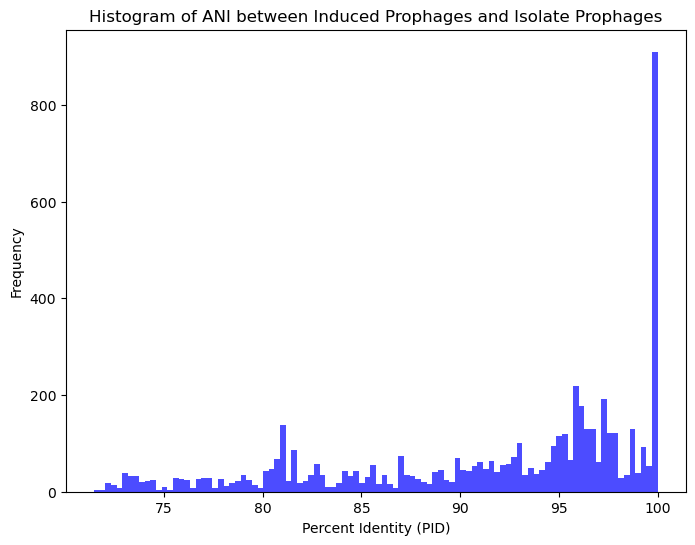

In [103]:
# plot histogram of anicalc pid
anicalc = pl.read_csv('induced_v_isolate.anicalc.tsv', separator='\t')

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.hist(anicalc['pid'], bins=100, color='blue', alpha=0.7)
plt.title('Histogram of ANI between Induced Prophages and Isolate Prophages')
plt.xlabel('Percent Identity (PID)')
plt.ylabel('Frequency')
plt.show()

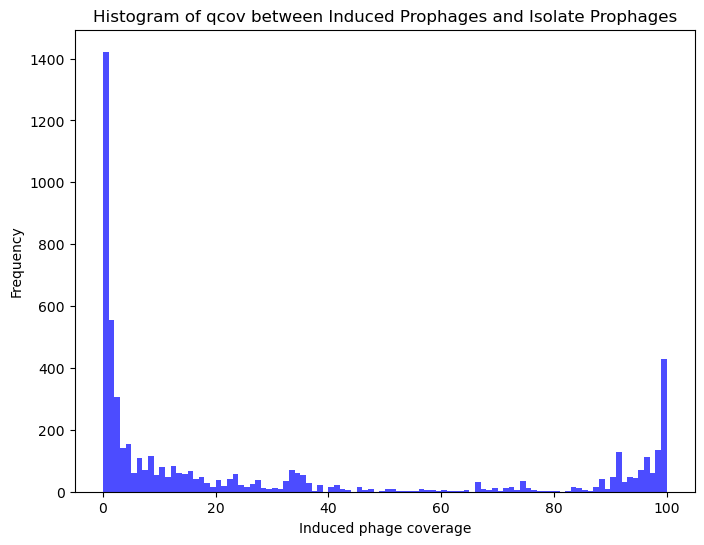

In [104]:
plt.figure(figsize=(8,6))
plt.hist(anicalc['qcov'], bins=100, color='blue', alpha=0.7)
plt.title('Histogram of qcov between Induced Prophages and Isolate Prophages')
plt.xlabel('Induced phage coverage')
plt.ylabel('Frequency')
plt.show()

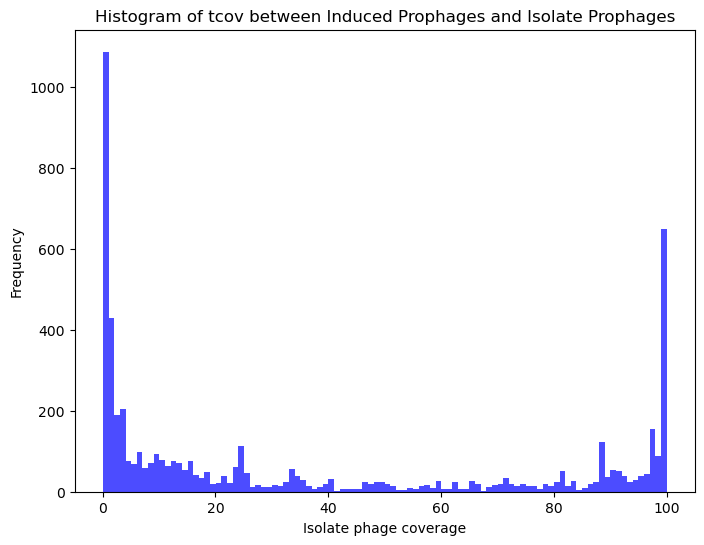

In [105]:
plt.figure(figsize=(8,6))
plt.hist(anicalc['tcov'], bins=100, color='blue', alpha=0.7)
plt.title('Histogram of tcov between Induced Prophages and Isolate Prophages')
plt.xlabel('Isolate phage coverage')
plt.ylabel('Frequency')
plt.show()

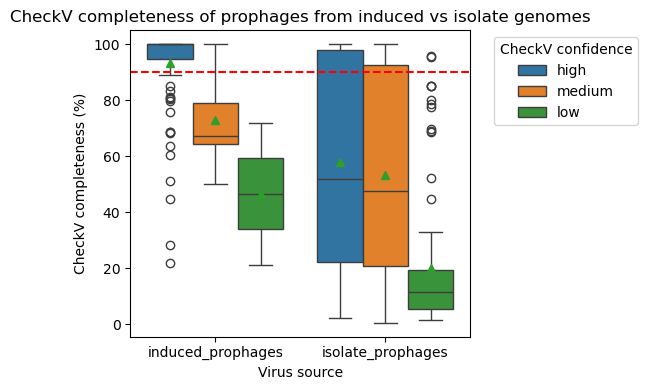

In [108]:
import polars as pl

# identify viruses in in both datasets
induced_viruses = (
    pl.read_csv('combined_induced_phages_genomad/combined_induced_phages_summary/combined_induced_phages_virus_summary.tsv', separator='\t')
        .join(
            pl.read_csv('combined_induced_phages_checkv/quality_summary.tsv', separator='\t', ignore_errors=True),
            left_on='seq_name',
            right_on='contig_id',
            how='left'
        )
        .join(
            pl.read_csv('combined_induced_phages_genomad/combined_induced_phages_find_proviruses/combined_induced_phages_provirus.tsv', separator='\t', ignore_errors=True),
            on='seq_name',
            how='left'
        )
        .filter(
            (pl.col('virus_score') >= 0.9) &
            (pl.col('length') >= 2000)
        )
        .with_columns([
            pl.when(pl.col('completeness_method').str.contains('high-confidence'))
                .then(pl.lit('high'))
                .when(pl.col('completeness_method').str.contains('medium-confidence'))
                .then(pl.lit('medium'))
                .when(pl.col('completeness_method').str.contains('low'))
                .then(pl.lit('low'))
                .alias('checkv_confidence'),
            pl.lit('induced_prophages').alias('source')
        ])
)

# identify isolate viruses that are identical to induced
induced_in_isolates = set(
    pl.read_csv('induced_v_isolate.anicalc.tsv', separator='\t')
        .filter(
            (pl.col('pid') >= 100) &
            (
                (pl.col('qcov') >= 100) |
                (pl.col('tcov') >= 100)
            )
        )['tname']
)

# isolate viruses
isolate_viruses = (
    pl.read_csv('combined_bacterial_isolates_genomad/combined_bacterial_isolates_summary/combined_bacterial_isolates_virus_summary.tsv', separator='\t')
        .join(
            pl.read_csv('combined_bacterial_isolates_checkv/quality_summary.tsv', separator='\t', ignore_errors=True),
            left_on='seq_name',
            right_on='contig_id',
            how='left'
        )
        .join(
            pl.read_csv('combined_bacterial_isolates_genomad/combined_bacterial_isolates_find_proviruses/combined_bacterial_isolates_provirus.tsv', separator='\t', ignore_errors=True),
            on='seq_name',
            how='left'
        )
        .filter(
            (pl.col('virus_score') >= 0.9) &
            (pl.col('length') >= 2000) &
            (~pl.col('completeness').str.contains('NA')) &
            (~pl.col('seq_name').is_in(induced_in_isolates))
        )
        .with_columns([
            pl.when(pl.col('completeness_method').str.contains('high-confidence'))
                .then(pl.lit('high'))
                .when(pl.col('completeness_method').str.contains('medium-confidence'))
                .then(pl.lit('medium'))
                .when(pl.col('completeness_method').str.contains('low'))
                .then(pl.lit('low'))
                .alias('checkv_confidence'),
            pl.col('completeness').cast(pl.Float64),
            pl.lit('isolate_prophages').alias('source'),
        ])
)

combined = pl.concat([induced_viruses[['seq_name', 'source', 'length', 'virus_score', 'n_hallmarks', 'v_vs_c_score', 'in_seq_edge', 'integrases', 'host_genes', 'viral_genes', 'completeness', 'checkv_confidence']], isolate_viruses[['seq_name', 'source', 'length', 'virus_score', 'n_hallmarks', 'v_vs_c_score', 'in_seq_edge', 'integrases', 'host_genes', 'viral_genes', 'completeness', 'checkv_confidence']]])

# create seaborn boxplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(
    data=combined,
    x='source',
    y='completeness',
    hue='checkv_confidence',
    order=['induced_prophages', 'isolate_prophages'],
    hue_order=['high', 'medium', 'low'],
    showmeans=True
)
plt.ylabel('CheckV completeness (%)')
plt.xlabel('Virus source')
plt.title('CheckV completeness of prophages from induced vs isolate genomes')
plt.legend(title='CheckV confidence', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
# plot a horizontal line at y=90
plt.axhline(y=90, color='r', linestyle='--', label='90% completeness')
plt.show()

In [115]:
print("Number of induced prophages:",
    combined.filter(
        (pl.col('source') == 'induced_prophages')
    ).shape[0]
)
print("Number of induced prophages >= 90% complete:",
    combined.filter(
        (pl.col('source') == 'induced_prophages') &
        (pl.col('completeness') >= 90) &
        ((pl.col('host_genes') <= 2) | (pl.col('host_genes')/pl.col('viral_genes') < 1))
    ).shape[0]
)
print("Proportion of induced prophages with >90% completeness:",
    combined.filter(
        (pl.col('source') == 'induced_prophages') &
        (pl.col('completeness') >= 90) &
        ((pl.col('host_genes') <= 2) | (pl.col('host_genes')/pl.col('viral_genes') < 1))
    ).shape[0] / combined.filter(
        (pl.col('source') == 'induced_prophages')
    ).shape[0]
)

print("Number of uninduced prophages:",
    combined.filter(
        (pl.col('source') == 'isolate_prophages')
    ).shape[0]
)
print("Number of uninduced prophages >= 90% complete:",
    combined.filter(
        (pl.col('source') == 'isolate_prophages') &
        (pl.col('completeness') >= 90) &
        ((pl.col('host_genes') <= 2) | (pl.col('host_genes')/pl.col('viral_genes') < 1))
    ).shape[0]
)
print("Proportion of isolate prophages with >90% completeness:",
    combined.filter(
        (pl.col('source') == 'isolate_prophages') &
        (pl.col('completeness') >= 90) &
        ((pl.col('host_genes') <= 2) | (pl.col('host_genes')/pl.col('viral_genes') < 1))
    ).shape[0] / combined.filter(
        (pl.col('source') == 'isolate_prophages')
    ).shape[0]
)

Number of induced prophages: 136
Number of induced prophages >= 90% complete: 87
Proportion of induced prophages with >90% completeness: 0.6397058823529411
Number of uninduced prophages: 1023
Number of uninduced prophages >= 90% complete: 317
Proportion of isolate prophages with >90% completeness: 0.3098729227761486


In [69]:
print(
    combined
        .filter(pl.col('completeness') >= 90)
        .group_by('source')
        .agg([
            pl.col('n_hallmarks').mean().alias('avg_n_hallmarks'),
            pl.col('n_hallmarks').median().alias('median_n_hallmarks')
        ])
)

print(
    combined
        .filter(pl.col('completeness') >= 90)
        .group_by('source')
        .agg([
            pl.col('virus_score').mean().alias('avg_virus_score'),
            pl.col('virus_score').median().alias('median_virus_score')
        ])
)

print(
    combined
        .filter(pl.col('completeness') >= 90)
        .group_by('source')
        .agg([
            pl.col('length').mean().alias('avg_length'),
            pl.col('length').median().alias('median_length')
        ])
)

print(
    combined
        .filter(pl.col('completeness') >= 90)
        .group_by('source')
        .agg([
            pl.col('host_genes').mean().alias('avg_host_genes'),
            pl.col('host_genes').median().alias('median_host_genes')
        ])
)

shape: (2, 3)
┌───────────────────┬─────────────────┬────────────────────┐
│ source            ┆ avg_n_hallmarks ┆ median_n_hallmarks │
│ ---               ┆ ---             ┆ ---                │
│ str               ┆ f64             ┆ f64                │
╞═══════════════════╪═════════════════╪════════════════════╡
│ induced_prophages ┆ 9.685393        ┆ 10.0               │
│ isolate_prophages ┆ 12.271255       ┆ 10.0               │
└───────────────────┴─────────────────┴────────────────────┘
shape: (2, 3)
┌───────────────────┬─────────────────┬────────────────────┐
│ source            ┆ avg_virus_score ┆ median_virus_score │
│ ---               ┆ ---             ┆ ---                │
│ str               ┆ f64             ┆ f64                │
╞═══════════════════╪═════════════════╪════════════════════╡
│ isolate_prophages ┆ 0.999066        ┆ 0.9994             │
│ induced_prophages ┆ 0.99952         ┆ 0.9996             │
└───────────────────┴─────────────────┴──────────────────